# Library imports

In [420]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report


# Load the cohort

In [78]:
df = pd.read_csv("merged_chd_model_v2.csv")

In [79]:
df

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,1014.000000
1,10949596,26086151,31406916,0,1,0,0,79,M,WHITE,...,14.0,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,NaN
2,11038900,29967401,30447128,1,1,0,0,76,M,UNKNOWN,...,22.0,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,NaN
3,11038900,29967401,33744055,0,1,0,0,76,M,UNKNOWN,...,16.0,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,1.666667
4,11384756,21111442,31242950,0,1,0,0,61,F,WHITE,...,17.0,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,0,1,65,M,WHITE,...,13.0,135.0,4.4,95.0,13.3,12.8,1.6,NaN,0,NaN
15441,19995780,21942461,36805359,0,0,0,1,84,M,WHITE,...,11.0,134.0,5.0,145.0,11.2,14.9,1.6,NaN,0,NaN
15442,19995790,22970553,34995866,0,0,0,1,66,M,WHITE,...,18.0,133.0,4.4,126.0,10.9,10.9,2.3,NaN,0,NaN
15443,19996673,29017569,38026904,0,0,0,1,72,F,WHITE,...,38.0,135.0,5.4,109.0,8.4,9.8,NaN,2.27,0,NaN


# Inspect data types

In [80]:
str(df.dtypes["subject_id"])

'int64'

In [81]:
X_df = df.drop(columns="y")
y = df.y

In [308]:
numerical_cols

['is_mi',
 'is_pcr',
 'is_cbs',
 'age',
 'cci',
 'myocardial_infarct',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'cerebrovascular_disease',
 'dementia',
 'chronic_pulmonary_disease',
 'rheumatic_disease',
 'peptic_ulcer_disease',
 'mild_liver_disease',
 'diabetes_without_cc',
 'diabetes_with_cc',
 'paraplegia',
 'renal_disease',
 'malignant_cancer',
 'severe_liver_disease',
 'metastatic_solid_tumor',
 'aids',
 'first_day_sofa',
 'apsiii_score',
 'oasis_score',
 'heart_rate_mean',
 'sbp_mean',
 'dbp_mean',
 'mbp_mean',
 'resp_rate_mean',
 'temperature_mean',
 'spo2_mean',
 'glucose_mean',
 'creatinine_last_24h',
 'bun_last_24h',
 'sodium_last_24h',
 'potassium_last_24h',
 'glucose_last_24h',
 'hemoglobin_last_24h',
 'wbc_last_24h',
 'lactate_last_24h',
 'troponin_last_24h',
 'n_prior_icu_stays',
 'prev_gap_days']

In [312]:
set(X_df['is_mi'].unique()) == set([0,1])

True

In [313]:
[col for col in X_df.columns if set(X_df[col].unique()) == set([0,1])]

['is_mi',
 'is_pcr',
 'is_cbs',
 'myocardial_infarct',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'cerebrovascular_disease',
 'dementia',
 'chronic_pulmonary_disease',
 'rheumatic_disease',
 'peptic_ulcer_disease',
 'mild_liver_disease',
 'diabetes_without_cc',
 'diabetes_with_cc',
 'paraplegia',
 'renal_disease',
 'malignant_cancer',
 'severe_liver_disease',
 'metastatic_solid_tumor',
 'aids']

In [316]:
# inspect variable 


numerical_cols = [col for col in X_df.columns if "int" in str(df.dtypes[col]).lower() or "float" in str(df.dtypes[col]).lower()]
binary_cols = [col for col in X_df.columns if set(X_df[col].unique()) == set([0,1])]
non_binary_numerical_cols = [col for col in numerical_cols if col not in binary_cols]
categorical_cols =  [col for col in X_df.columns if col not in numerical_cols]

IDENTIFIER_COLS = ["subject_id", "hadm_id", "stay_id"]

numerical_cols = [col for col in numerical_cols if col not in IDENTIFIER_COLS]
binary_cols = [col for col in binary_cols if col not in IDENTIFIER_COLS]
non_binary_numerical_cols = [col for col in non_binary_numerical_cols if col not in IDENTIFIER_COLS]
categorical_cols = [col for col in categorical_cols if col not in IDENTIFIER_COLS]


#print(f"We have {len(numerical_cols)} numeric columns, {len(categorical_cols)} categorical columns, and {len(IDENTIFIER_COLS)} identifier columns.")

print(f"{len(non_binary_numerical_cols)} Non-binary Numeric cols below\n", sorted(non_binary_numerical_cols), "\n-----------------------------------")

print(f"{len(binary_cols)} Binary cols below\n", sorted(binary_cols), "\n-----------------------------------")

print(f"{len(categorical_cols)} Categorical cols below\n", categorical_cols, "\n-----------------------------------")

print(f"{len(IDENTIFIER_COLS)} Identifier cols below\n", IDENTIFIER_COLS, "\n-----------------------------------")

24 Non-binary Numeric cols below
 ['age', 'apsiii_score', 'bun_last_24h', 'cci', 'creatinine_last_24h', 'dbp_mean', 'first_day_sofa', 'glucose_last_24h', 'glucose_mean', 'heart_rate_mean', 'hemoglobin_last_24h', 'lactate_last_24h', 'mbp_mean', 'n_prior_icu_stays', 'oasis_score', 'potassium_last_24h', 'prev_gap_days', 'resp_rate_mean', 'sbp_mean', 'sodium_last_24h', 'spo2_mean', 'temperature_mean', 'troponin_last_24h', 'wbc_last_24h'] 
-----------------------------------
20 Binary cols below
 ['aids', 'cerebrovascular_disease', 'chronic_pulmonary_disease', 'congestive_heart_failure', 'dementia', 'diabetes_with_cc', 'diabetes_without_cc', 'is_cbs', 'is_mi', 'is_pcr', 'malignant_cancer', 'metastatic_solid_tumor', 'mild_liver_disease', 'myocardial_infarct', 'paraplegia', 'peptic_ulcer_disease', 'peripheral_vascular_disease', 'renal_disease', 'rheumatic_disease', 'severe_liver_disease'] 
-----------------------------------
6 Categorical cols below
 ['gender', 'race', 'admission_type', 'insu

# Summary statistics & NA values of numerical columns



## The goal
MOST important thing to identify to clean the data **to inform what to do after splitting** 
1. Outliers that do not make sense (e.g. glucose 999999)
2. What to do with missing values? are they missing at random or not?
   - E.g. `prev_gap_days` is not independent to `n_prior_icu_stays`. For example, if `n_prior_icu_stays==0` then `prev_gap_days` is null


## Function for summ stats per column (e.g. subcohort)

In [155]:
def summ_stats_and_NA_per_column(X_df, y, col=None, sort_by_na_vals=True):

    """
    Given measurements in a cohort and a variable 'col',
    display the summary statistics and NA values from the data for each column value 
    """

    sort_key = "na_prop" if sort_by_na_vals else "diff_max_3rd_quartile"

    # if we wanna view summary stats for entire dataset
    if col is None:
        
        summ_stats = X_df.drop(columns=IDENTIFIER_COLS).describe()

        summ_stats.loc['skewness'] = summ_stats.skew(numeric_only=True)

        summ_stats = summ_stats.T
        
        summ_stats = summ_stats.assign(diff_max_3rd_quartile= (summ_stats['max'] - summ_stats['75%']),
                                      na_vals = (X_df.shape[0] - summ_stats['count']),
                                      na_prop = 100*(X_df.shape[0] - summ_stats['count'])/X_df.shape[0] )

        # summary stats
        print("Summary statistics (whole dataset)")

        
        
        display(
            round(
            summ_stats.\
                    sort_values(by=sort_key, ascending=False),
              1)
        )
        print("-"*50)

        # class distribution
        print("Class distribution (whole dataset)")

        display(
            pd.concat([y.value_counts(),
                       y.value_counts(normalize=True)],
                      axis=1)
        )
        
        print("\n")

        return

    # if a column name is specified
    for col_value in sorted(X_df[col].unique()):
        
        print(f"Displaying summary stats and NA values for {col_value} below")
        X_df_sub = X_df[X_df[col] == col_value]

        # summary stats
        print(f"Summary statistics for {col} == {col_value}")
        summ_stats = X_df_sub.drop(columns=IDENTIFIER_COLS).describe()

        summ_stats.loc['skewness'] = summ_stats.skew(numeric_only=True)

        summ_stats = summ_stats.T

        
        summ_stats = summ_stats.assign(diff_max_3rd_quartile= (summ_stats['max'] - summ_stats['75%']),
                                      na_vals = (X_df_sub.shape[0] - summ_stats['count']),
                                      na_prop = 100*(X_df_sub.shape[0] - summ_stats['count'])/X_df_sub.shape[0] )
        
        display(
            round(
            summ_stats.\
                    sort_values(by=sort_key, ascending=False),
              1)
        )

        # class distribution
        print("-"*50)
        print(f"Class distribution for {col} == {col_value}")
        display(
            pd.concat([y[X_df_sub.index].value_counts(),
                   y[X_df_sub.index].value_counts(normalize=True)],
                  axis=1)
        )

        
        print("\n")
    



## Entire cohort

In [156]:
summ_stats_and_NA_per_column(X_df, y, col=None, sort_by_na_vals=True)

Summary statistics (whole dataset)


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,2669.0,329.6,690.7,0.0,1.4,9.8,272.0,4956.0,1.8,4684.0,12776.0,82.7
troponin_last_24h,5903.0,2.9,3.9,0.0,0.6,1.4,3.6,51.8,2.8,48.3,9542.0,61.8
lactate_last_24h,11059.0,2.0,1.7,0.3,1.3,1.7,2.3,29.0,2.8,26.7,4386.0,28.4
temperature_mean,14300.0,36.7,0.5,30.8,36.5,36.7,36.9,40.0,2.8,3.0,1145.0,7.4
wbc_last_24h,15244.0,12.4,9.3,0.0,8.8,11.4,14.5,568.0,2.8,553.5,201.0,1.3
hemoglobin_last_24h,15246.0,10.6,1.9,3.9,9.3,10.5,11.8,19.4,2.8,7.6,199.0,1.3
potassium_last_24h,15260.0,4.3,0.5,1.3,4.0,4.3,4.6,10.0,2.8,5.4,185.0,1.2
sodium_last_24h,15286.0,137.6,3.6,97.0,136.0,138.0,140.0,175.0,2.8,35.0,159.0,1.0
bun_last_24h,15295.0,23.4,17.4,2.0,13.0,18.0,27.0,198.0,2.8,171.0,150.0,1.0
creatinine_last_24h,15295.0,1.4,1.3,0.1,0.8,1.0,1.4,18.0,2.8,16.6,150.0,1.0


--------------------------------------------------
Class distribution (whole dataset)


,count,proportion
y,,
0,14531,0.940822
1,914,0.059178


In [157]:
summ_stats_and_NA_per_column(X_df, y, col=None, sort_by_na_vals=False)

Summary statistics (whole dataset)


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
glucose_mean,15297.0,219.6,8113.8,51.0,120.1,131.7,151.7,999999.0,2.8,999847.3,148.0,1.0
prev_gap_days,2669.0,329.6,690.7,0.0,1.4,9.8,272.0,4956.0,1.8,4684.0,12776.0,82.7
glucose_last_24h,15300.0,133.7,57.5,0.1,104.0,120.0,144.0,1000.0,2.8,856.0,145.0,0.9
wbc_last_24h,15244.0,12.4,9.3,0.0,8.8,11.4,14.5,568.0,2.8,553.5,201.0,1.3
bun_last_24h,15295.0,23.4,17.4,2.0,13.0,18.0,27.0,198.0,2.8,171.0,150.0,1.0
apsiii_score,15445.0,40.5,19.7,3.0,27.0,36.0,48.0,164.0,2.8,116.0,0.0,0.0
sbp_mean,15407.0,113.6,12.7,34.2,105.6,112.1,119.8,215.9,2.8,96.1,38.0,0.2
mbp_mean,15410.0,76.3,9.1,29.0,70.6,75.1,80.6,159.5,2.8,78.9,35.0,0.2
heart_rate_mean,15422.0,81.1,12.4,33.5,73.2,80.4,88.2,162.4,2.8,74.2,23.0,0.1
dbp_mean,15407.0,60.3,9.8,20.8,53.9,59.1,65.5,136.0,2.8,70.5,38.0,0.2


--------------------------------------------------
Class distribution (whole dataset)


,count,proportion
y,,
0,14531,0.940822
1,914,0.059178


## MI cohort

In [160]:
summ_stats_and_NA_per_column(X_df, y, col="is_mi")

Displaying summary stats and NA values for 0 below
Summary statistics for is_mi == 0


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,1376.0,259.1,670.9,0.0,0.4,3.2,57.7,4956.0,2.4,4898.2,8639.0,86.3
troponin_last_24h,2404.0,2.7,3.8,0.0,0.4,1.4,3.5,51.8,2.8,48.3,7611.0,76.0
lactate_last_24h,7960.0,1.9,1.3,0.3,1.3,1.7,2.2,25.0,2.8,22.8,2055.0,20.5
temperature_mean,9088.0,36.7,0.4,32.2,36.5,36.7,36.9,39.2,2.8,2.3,927.0,9.3
potassium_last_24h,9936.0,4.4,0.5,1.3,4.1,4.4,4.7,10.0,2.8,5.3,79.0,0.8
glucose_mean,9947.0,255.2,10061.8,51.0,121.2,130.8,145.7,999999.0,2.8,999853.3,68.0,0.7
wbc_last_24h,9954.0,12.4,6.3,0.0,9.2,11.7,14.6,292.5,2.8,277.9,61.0,0.6
hemoglobin_last_24h,9958.0,10.5,1.7,3.9,9.3,10.4,11.6,18.5,2.8,6.9,57.0,0.6
sodium_last_24h,9962.0,137.4,3.2,97.0,136.0,137.0,139.0,175.0,2.8,36.0,53.0,0.5
bun_last_24h,9971.0,20.8,14.5,2.0,13.0,16.0,23.0,183.0,2.8,160.0,44.0,0.4


--------------------------------------------------
Class distribution for is_mi == 0


,count,proportion
y,,
0,9502,0.948777
1,513,0.051223




Displaying summary stats and NA values for 1 below
Summary statistics for is_mi == 1


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,1293.0,404.7,703.6,0.0,4.1,71.9,478.2,4267.8,2.4,3789.6,4137.0,76.2
lactate_last_24h,3099.0,2.3,2.5,0.4,1.2,1.6,2.3,29.0,2.8,26.7,2331.0,42.9
troponin_last_24h,3499.0,2.9,3.9,0.0,0.7,1.5,3.6,51.8,2.8,48.3,1931.0,35.6
temperature_mean,5212.0,36.7,0.5,30.8,36.6,36.8,37.0,40.0,2.8,3.0,218.0,4.0
hemoglobin_last_24h,5288.0,10.9,2.1,3.9,9.3,10.8,12.3,19.4,2.8,7.1,142.0,2.6
wbc_last_24h,5290.0,12.3,13.1,0.0,8.1,10.8,14.3,568.0,2.8,553.7,140.0,2.6
sodium_last_24h,5324.0,138.1,4.2,97.0,136.0,138.0,140.0,165.0,2.8,25.0,106.0,2.0
bun_last_24h,5324.0,28.2,21.0,3.0,14.0,21.0,35.0,198.0,2.8,163.0,106.0,2.0
creatinine_last_24h,5324.0,1.6,1.5,0.2,0.8,1.1,1.7,18.0,2.8,16.3,106.0,2.0
potassium_last_24h,5324.0,4.2,0.6,1.6,3.9,4.2,4.5,10.0,2.8,5.5,106.0,2.0


--------------------------------------------------
Class distribution for is_mi == 1


,count,proportion
y,,
0,5029,0.926151
1,401,0.073849


## PCR cohort

In [161]:
summ_stats_and_NA_per_column(X_df, y, col="is_pcr")

Displaying summary stats and NA values for 0 below
Summary statistics for is_pcr == 0


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,2395.0,349.2,710.4,0.0,1.5,14.2,316.1,4956.0,2.0,4639.9,10701.0,81.7
troponin_last_24h,4121.0,2.7,3.8,0.0,0.6,1.4,3.3,51.8,2.8,48.5,8975.0,68.5
lactate_last_24h,10118.0,2.0,1.6,0.3,1.3,1.7,2.3,29.0,2.8,26.7,2978.0,22.7
temperature_mean,12019.0,36.7,0.5,30.8,36.5,36.7,36.9,40.0,2.8,3.0,1077.0,8.2
potassium_last_24h,12934.0,4.4,0.5,1.3,4.0,4.3,4.6,10.0,2.8,5.4,162.0,1.2
hemoglobin_last_24h,12938.0,10.5,1.8,3.9,9.3,10.4,11.6,19.4,2.8,7.8,158.0,1.2
wbc_last_24h,12939.0,12.6,9.6,0.0,9.0,11.6,14.7,568.0,2.8,553.3,157.0,1.2
sodium_last_24h,12961.0,137.6,3.5,97.0,136.0,138.0,140.0,165.0,2.8,25.0,135.0,1.0
bun_last_24h,12973.0,22.8,16.9,2.0,13.0,17.0,26.0,198.0,2.8,172.0,123.0,0.9
creatinine_last_24h,12973.0,1.4,1.3,0.1,0.8,1.0,1.3,18.0,2.8,16.7,123.0,0.9


--------------------------------------------------
Class distribution for is_pcr == 0


,count,proportion
y,,
0,12316,0.94044
1,780,0.05956




Displaying summary stats and NA values for 1 below
Summary statistics for is_pcr == 1


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,274.0,158.8,451.8,0.0,0.6,3.1,12.0,3325.8,2.7,3313.8,2075.0,88.3
lactate_last_24h,941.0,2.2,2.6,0.4,1.2,1.5,2.1,20.7,2.8,18.6,1408.0,59.9
troponin_last_24h,1782.0,3.1,4.1,0.0,0.5,1.7,4.1,51.8,2.8,47.8,567.0,24.1
temperature_mean,2281.0,36.7,0.5,32.2,36.5,36.7,36.9,38.5,2.8,1.6,68.0,2.9
wbc_last_24h,2305.0,11.3,7.1,0.0,7.8,10.1,13.2,131.0,2.8,117.8,44.0,1.9
glucose_mean,2305.0,157.1,61.7,51.0,116.5,138.3,179.3,579.0,2.6,399.7,44.0,1.9
hemoglobin_last_24h,2308.0,11.3,2.2,3.9,9.6,11.3,13.0,18.5,2.8,5.5,41.0,1.7
glucose_last_24h,2319.0,148.0,69.8,15.0,108.0,127.0,163.0,1000.0,2.2,837.0,30.0,1.3
bun_last_24h,2322.0,26.8,19.9,3.0,14.0,20.0,32.0,183.0,2.8,151.0,27.0,1.1
creatinine_last_24h,2322.0,1.6,1.5,0.2,0.8,1.0,1.6,14.8,2.8,13.2,27.0,1.1


--------------------------------------------------
Class distribution for is_pcr == 1


,count,proportion
y,,
0,2215,0.942954
1,134,0.057046


## CBS cohort

In [159]:
summ_stats_and_NA_per_column(X_df, y, col="is_cbs")

Displaying summary stats and NA values for 0 below
Summary statistics for is_cbs == 0


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
prev_gap_days,1567.0,361.7,672.9,0.0,2.8,40.0,395.4,4267.8,2.2,3872.3,6212.0,79.9
lactate_last_24h,4040.0,2.3,2.5,0.4,1.2,1.6,2.2,29.0,2.8,26.8,3739.0,48.1
troponin_last_24h,5281.0,3.0,4.0,0.0,0.6,1.6,3.7,51.8,2.8,48.1,2498.0,32.1
temperature_mean,7493.0,36.7,0.5,30.8,36.6,36.8,37.0,40.0,2.8,3.0,286.0,3.7
wbc_last_24h,7595.0,12.0,11.7,0.0,8.0,10.6,14.0,568.0,2.8,554.0,184.0,2.4
hemoglobin_last_24h,7596.0,11.0,2.1,3.9,9.4,10.9,12.6,19.4,2.8,6.8,183.0,2.4
bun_last_24h,7646.0,27.8,20.7,3.0,14.0,21.0,34.0,198.0,2.8,164.0,133.0,1.7
creatinine_last_24h,7646.0,1.6,1.5,0.2,0.8,1.1,1.7,18.0,2.8,16.3,133.0,1.7
glucose_last_24h,7648.0,145.7,70.5,0.1,107.0,126.0,160.0,1000.0,2.8,840.0,131.0,1.7
sodium_last_24h,7649.0,137.9,4.1,97.0,136.0,138.0,140.0,175.0,2.8,35.0,130.0,1.7


--------------------------------------------------
Class distribution for is_cbs == 0


,count,proportion
y,,
0,7244,0.931225
1,535,0.068775




Displaying summary stats and NA values for 1 below
Summary statistics for is_cbs == 1


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
troponin_last_24h,622.0,1.7,2.6,0.0,0.2,0.7,2.1,19.6,2.8,17.5,7044.0,91.9
prev_gap_days,1102.0,284.0,713.0,0.0,0.4,3.2,79.6,4956.0,2.5,4876.4,6564.0,85.6
temperature_mean,6807.0,36.7,0.4,32.9,36.5,36.7,36.9,39.2,2.8,2.3,859.0,11.2
lactate_last_24h,7019.0,1.9,1.0,0.3,1.3,1.8,2.3,25.0,2.8,22.7,647.0,8.4
potassium_last_24h,7610.0,4.4,0.5,1.3,4.1,4.4,4.7,7.3,2.8,2.6,56.0,0.7
sodium_last_24h,7637.0,137.4,3.0,116.0,136.0,137.0,139.0,153.0,2.8,14.0,29.0,0.4
glucose_mean,7642.0,284.8,11479.3,73.5,121.8,130.0,141.4,999999.0,2.8,999857.6,24.0,0.3
bun_last_24h,7649.0,19.0,11.9,2.0,12.0,16.0,21.0,150.0,2.8,129.0,17.0,0.2
creatinine_last_24h,7649.0,1.2,1.1,0.1,0.8,0.9,1.2,16.6,2.8,15.4,17.0,0.2
wbc_last_24h,7649.0,12.7,6.0,0.0,9.7,12.1,15.0,292.5,2.8,277.5,17.0,0.2


--------------------------------------------------
Class distribution for is_cbs == 1


,count,proportion
y,,
0,7287,0.950561
1,379,0.049439


## Remarks
- Most missingness lie in `prev_gap_days`, `troponin_last_24h`, `lactate_last_24h` in the entire cohort.

# Missingness of each column by cohort
- Since `troponin_last_24h` missingness primarily occurs in PCR cohort, and `lactate_last_24h` missingness primarily occurs in CBS cohort how about we obtain the number of missing values of features, **grouped by cohort**?

## NA values grouped by cohort

In [95]:
import pandas as pd
import numpy as np

# Convert one-hot cohort flags into a single label
def label_subcohort(df):
    df = df.copy()
    df["cohort"] = np.select(
        [
            df["is_mi"] == 1,
            df["is_pcr"] == 1,
            df["is_cbs"] == 1
        ],
        ["MI", "PCI", "CABG"],
        default="Other"
    )
    return df

merged_labeled = label_subcohort(X_df)

# Compute NA counts and proportions per cohort
def missing_by_cohort(df, cols=None):
    if cols is None:
        cols = df.columns
    res = (
        df.groupby("cohort")[cols]
        .apply(lambda g: g.isna().sum())
        .T  # easier to read: rows = variables, cols = cohorts
    )
    res["total_missing"] = df[cols].isna().sum()
    res["total_prop"] = res["total_missing"] / len(df)
    return res.sort_values("total_missing", ascending=False)

missing_table = missing_by_cohort(
    merged_labeled,
    cols=numerical_cols
)

display(missing_table[missing_table.total_prop > 0])


cohort,CABG,MI,PCI,total_missing,total_prop
prev_gap_days,6564,4137,2075,12776,0.827193
troponin_last_24h,7044,1931,567,9542,0.617805
lactate_last_24h,647,2331,1408,4386,0.283975
temperature_mean,859,218,68,1145,0.074134
wbc_last_24h,17,140,44,201,0.013014
hemoglobin_last_24h,16,142,41,199,0.012884
potassium_last_24h,56,106,23,185,0.011978
sodium_last_24h,29,106,24,159,0.010295
bun_last_24h,17,106,27,150,0.009712
creatinine_last_24h,17,106,27,150,0.009712


<Axes: xlabel='cohort'>

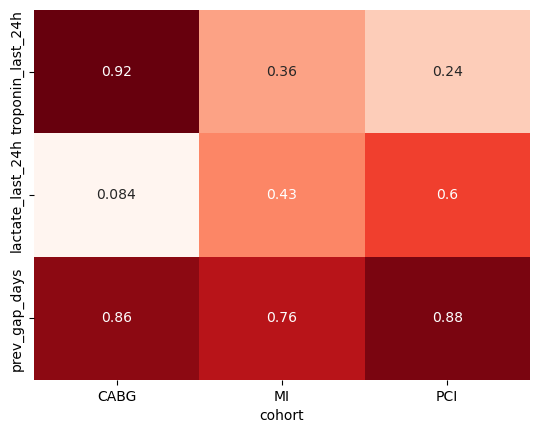

In [96]:
import seaborn as sns
sns.heatmap(
    merged_labeled.groupby("cohort")[["troponin_last_24h","lactate_last_24h","prev_gap_days"]].apply(lambda x: x.isna().mean()).T,
    annot=True, cmap="Reds", cbar=False
)


## Test: are missing values missing completely at random **across sub-cohorts**?

Idea: conduct a chi-squared contingency table test of association

cramers_v ∈ [0, 1]  roughly, with:
1. 0–0.1: negligible
2. 0.1–0.3: small
3. 0.3–0.5: moderate
4. Greater than 0.5: strong dependency.

Due to large cohort, many p-values will be “significant,” so we can focus more on effect size (Cramer’s V) to judge practical importance.

In [187]:
from scipy.stats import chi2_contingency
import pandas as pd

def chi2_missingness_by_cohort(df, features, cohort_col="cohort"):
    results = []
    n = len(df)

    for feature in features:
        # 3×2 contingency: cohort × {missing, not missing}
        tab = pd.crosstab(df[cohort_col], df[feature].isna())

        # run χ² test
        chi2, p, dof, expected = chi2_contingency(tab)

        # compute Cramér’s V
        r, c = tab.shape

        if min(r - 1, c - 1) == 0:
            cramers_v = None
        else:        
            cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

        results.append({
            "feature": feature,
            "chi2": chi2,
            "p_value": p,
            "dof": dof,
            "cramers_v": cramers_v,
            "n": n
        })

    return pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Run across all key features
# features = [
#     "troponin_last_24h","lactate_last_24h","prev_gap_days",
#     "creatinine_last_24h","sodium_last_24h","bun_last_24h"
# ]
features = numerical_cols

#chi2_missingness_by_cohort(X_df, features, cohort_col="cohort").assign(is_significant = results.p_value < 0.1 )

chi2_results = chi2_missingness_by_cohort(merged_labeled, numerical_cols + categorical_cols)
display(chi2_results)


,feature,chi2,p_value,dof,cramers_v,n
0,troponin_last_24h,5933.075976,0.000000e+00,2,0.619792,15445
1,lactate_last_24h,3214.949254,0.000000e+00,2,0.456240,15445
2,temperature_mean,321.845341,1.294709e-70,2,0.144354,15445
3,prev_gap_days,259.157242,5.305421e-57,2,0.129535,15445
4,hemoglobin_last_24h,149.268572,3.861369e-33,2,0.098308,15445
5,wbc_last_24h,144.470353,4.252667e-32,2,0.096715,15445
6,creatinine_last_24h,99.870086,2.058195e-22,2,0.080413,15445
7,bun_last_24h,99.870086,2.058195e-22,2,0.080413,15445
8,glucose_last_24h,99.576670,2.383422e-22,2,0.080294,15445
9,sodium_last_24h,77.274531,1.659773e-17,2,0.070733,15445


2        temperature_mean
3           prev_gap_days
4     hemoglobin_last_24h
5            wbc_last_24h
6            bun_last_24h
7     creatinine_last_24h
8        glucose_last_24h
9         sodium_last_24h
10           glucose_mean
11     potassium_last_24h
12              spo2_mean
13         resp_rate_mean
14               dbp_mean
15               sbp_mean
16               mbp_mean
17        heart_rate_mean
Name: feature, dtype: object

# Boxplots of numerical columns grouped by either cohort or any column

## Function

In [126]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_boxplots(
    df: pd.DataFrame,
    features: list,
    cohort_col: str = "cohort",           # expects a single column with values like {"MI","PCI","CABG"}
    group_by_cohort: bool = True,         # True -> grouped boxes per feature; False -> one box per feature
    cohorts_order: list | None = None,    # optional custom order for legend/boxes
    cols: int = 3,                        # grid columns
    figsize_per: tuple = (6.0, 7),      # per-subplot width, height (will be scaled by rows/cols)
    show_counts: bool = True,             # annotate n used per box
    clip_quantiles: tuple | None = None,  # e.g., (0.01, 0.99) to trim outliers visually
    title: str | None = None
):
    """
    Draw a grid of boxplots for given numeric features.
    - If group_by_cohort=True: each subplot shows multiple boxes (one per cohort) for that feature.
    - If group_by_cohort=False: each subplot shows a single box for that feature over the whole dataset.

    Notes:
      * NaNs are dropped per box.
      * If clip_quantiles is set, values are clipped to that quantile range before plotting (for visualization only).
    """
    if cohorts_order is None and group_by_cohort:
        cohorts_order = list(pd.Series(df[cohort_col].dropna().unique()).sort_values())

    k = len(features)
    if k == 0:
        raise ValueError("No features supplied.")

    rows = math.ceil(k / cols)
    fig_w = cols * figsize_per[0]
    fig_h = rows * figsize_per[1]
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]

        if group_by_cohort:
            data = []
            labels = []
            ns = []
            for cohort in cohorts_order:
                x = df.loc[df[cohort_col] == cohort, feat].astype(float)
                x = x.dropna()
                if clip_quantiles:
                    lo, hi = x.quantile(clip_quantiles[0]), x.quantile(clip_quantiles[1])
                    x = x.clip(lo, hi)
                data.append(x.values)

                # cohort label with non-NaN cohort size for the feature
                label = f"{str(cohort)}\n(n={len(x)})"
                labels.append(label)
                
                ns.append(len(x))

            bp = ax.boxplot(data, labels=labels, showfliers=True, patch_artist=True)
            # light fill for boxes
            for patch in bp['boxes']:
                patch.set_facecolor((0.9, 0.9, 0.95))

        else:
            x = df[feat].astype(float).dropna()
            if clip_quantiles:
                lo, hi = x.quantile(clip_quantiles[0]), x.quantile(clip_quantiles[1])
                x = x.clip(lo, hi)
            bp = ax.boxplot([x.values], labels=[feat], showfliers=True, patch_artist=True)
            bp['boxes'][0].set_facecolor((0.9, 0.9, 0.95))
            

        ax.set_title(feat, fontsize=10)
        ax.tick_params(axis='x', rotation=15)

    # Hide any unused axes
    for j in range(k, rows * cols):
        axes[j].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=12, y=0.995)
    fig.tight_layout()
    plt.show()


## Troponin and lactate by cohort

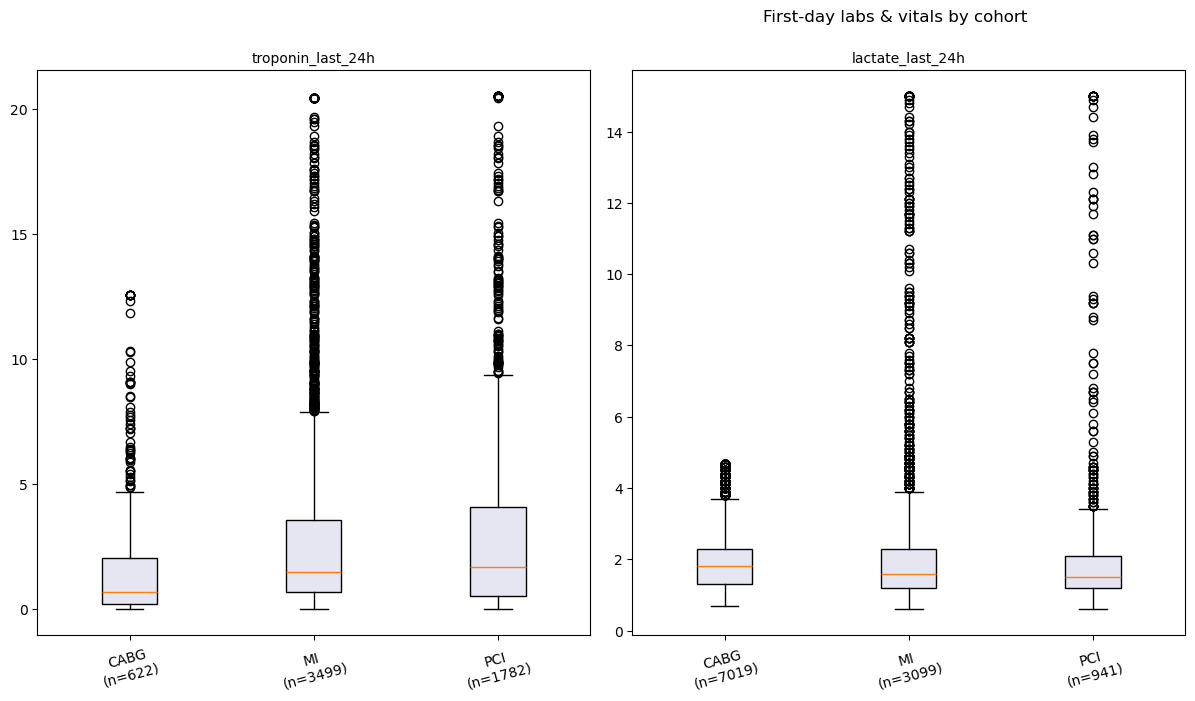

In [135]:
plot_feature_boxplots(
    merged_labeled,
    ["troponin_last_24h", "lactate_last_24h"],
    cohort_col="cohort",
    group_by_cohort=True,
    cohorts_order=["CABG","MI","PCI"],
    cols=3,
    clip_quantiles=(0.01, 0.99),
    title="First-day labs & vitals by cohort"
)

## Troponin and lactate by another col e.g. gender

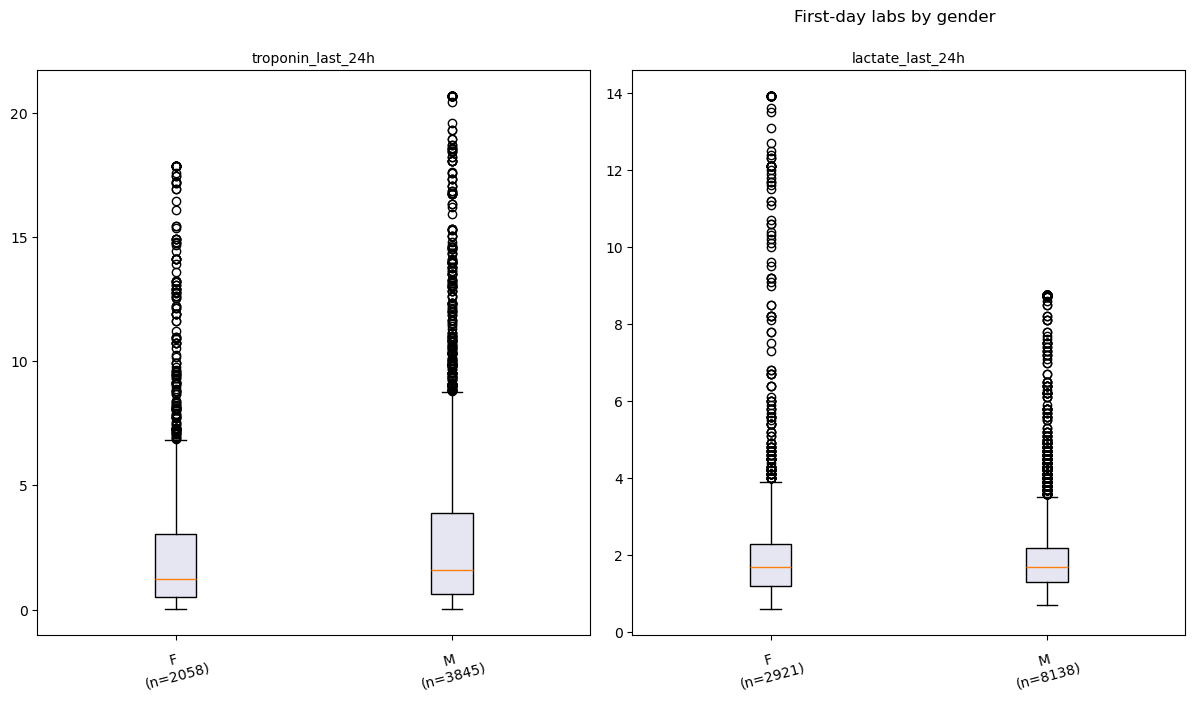

In [136]:
plot_feature_boxplots(
    merged_labeled,
    ["troponin_last_24h", "lactate_last_24h"],
    cohort_col="gender",
    group_by_cohort=True,
    cohorts_order=sorted(merged_labeled["gender"].dropna().unique()),
    cols=3,
    clip_quantiles=(0.01, 0.99),
    title="First-day labs by gender"
)


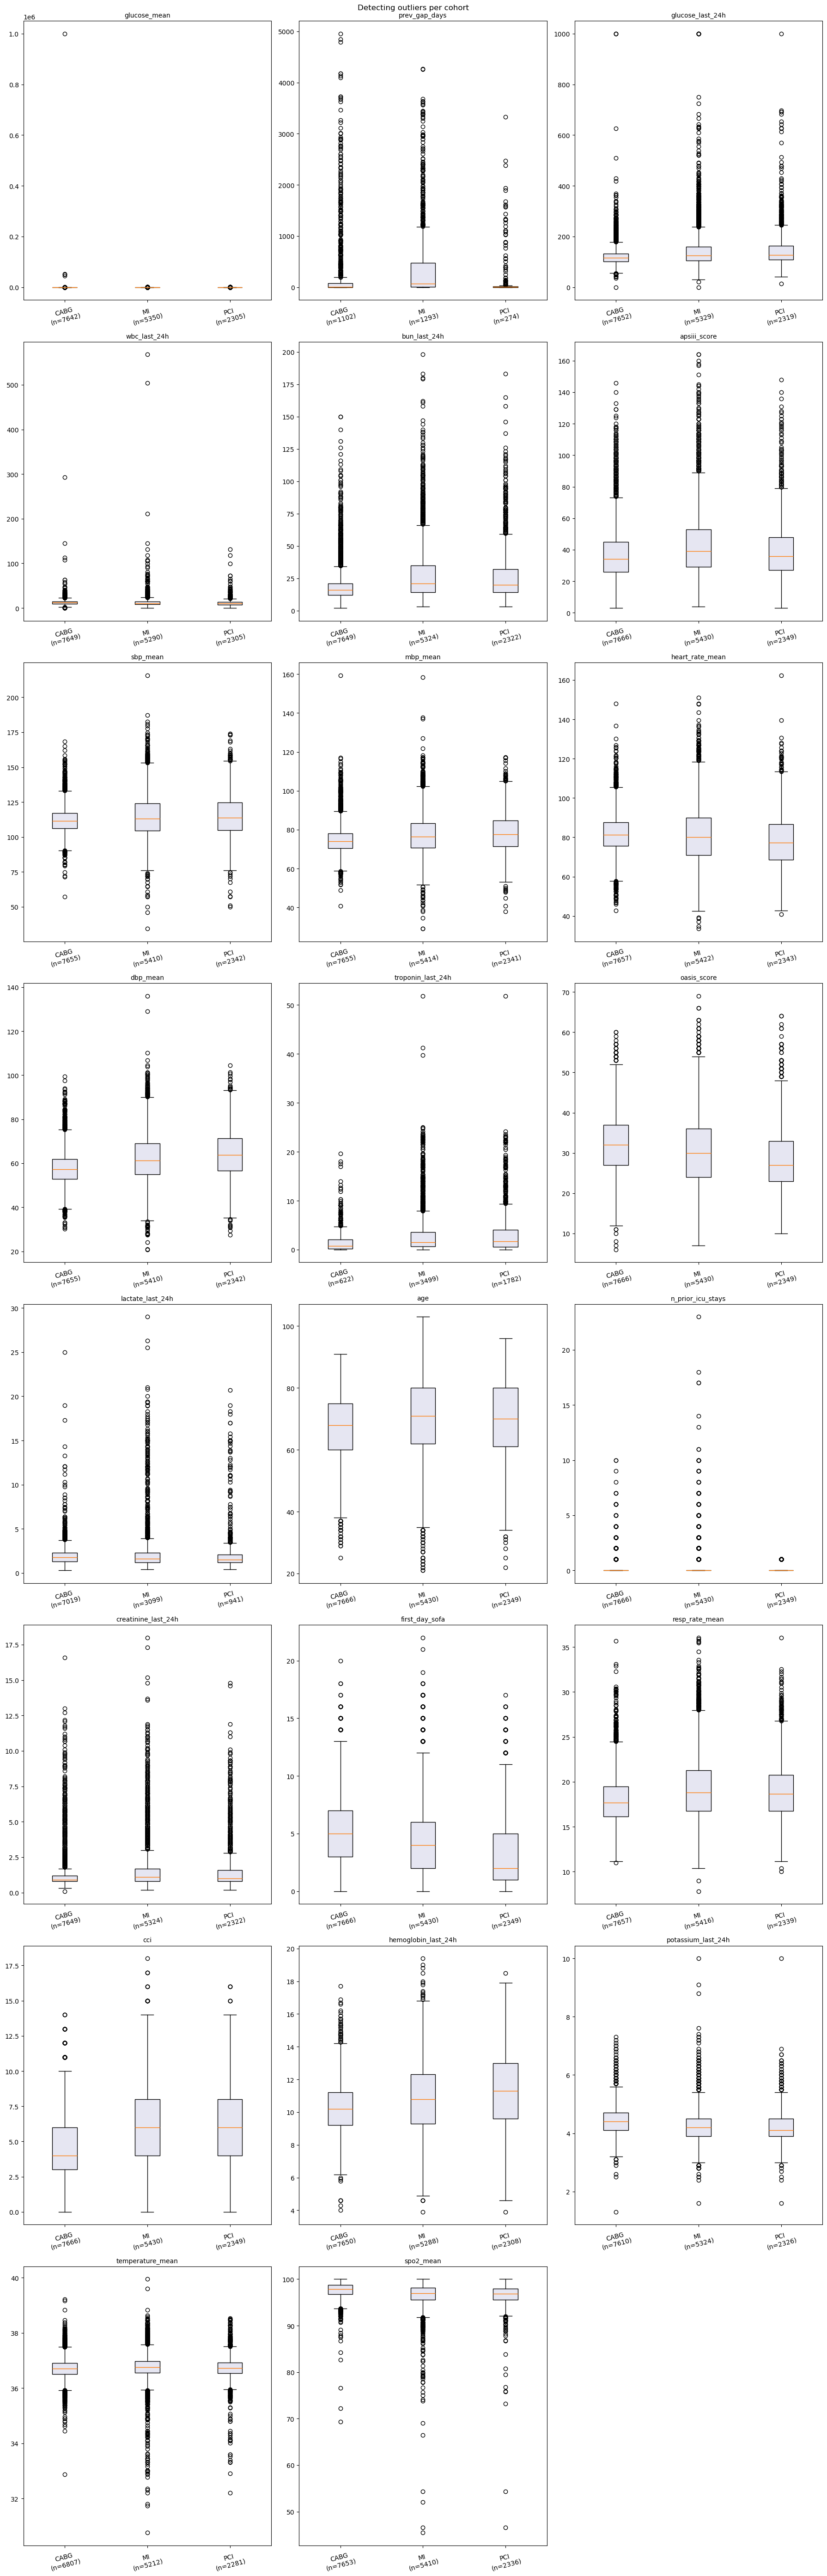

In [154]:
col = ["glucose_mean", "prev_gap_days", "glucose_last_24h", "wbc_last_24h", "bun_last_24h", "apsiii_score", "sbp_mean", "mbp_mean", "heart_rate_mean", "dbp_mean", "troponin_last_24h", "oasis_score", "lactate_last_24h", "age", "n_prior_icu_stays", "creatinine_last_24h", "first_day_sofa", "resp_rate_mean", "cci", "hemoglobin_last_24h", "potassium_last_24h", "temperature_mean", "spo2_mean"]
GROUP = "cohort"
plot_feature_boxplots(
    merged_labeled,
    col,
    cohort_col=GROUP,
    group_by_cohort=True,
    cohorts_order=sorted(merged_labeled[GROUP].dropna().unique()),
    cols=3,
    #clip_quantiles=(0.01, 0.99),
    title="Detecting outliers per cohort"
)


# Examine correlations/multicollinearity

## Correlation heatmap

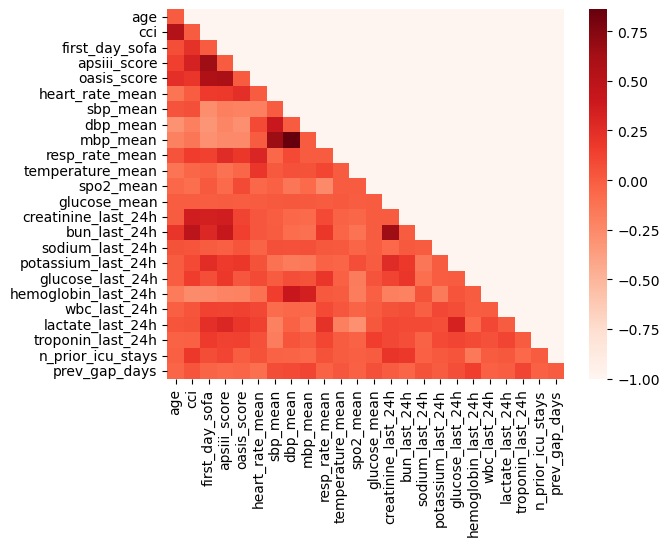

In [328]:

def examine_corr(cols, cmap='Reds'):

    corr_non_binary_num = X_df.loc[:,cols].copy().corr()

    # set diagonal elements to 0 instead of 1 and upper traingular to 0
    arr = corr_non_binary_num.to_numpy() # convert pandas df to numpy array
    np.fill_diagonal(arr, 0)

    # Get indices for the upper triangle (excluding the main diagonal)
    upper_indices = np.triu_indices_from(arr, k=1)
    
    # Set those elements to zero in-place
    arr[upper_indices] = -1
    
    corr_non_binary_num_modified = pd.DataFrame(arr, index=corr_non_binary_num.index, columns=corr_non_binary_num.columns)

    sns.heatmap(corr_non_binary_num_modified, cmap=cmap)

    
    
examine_corr(non_binary_numerical_cols)



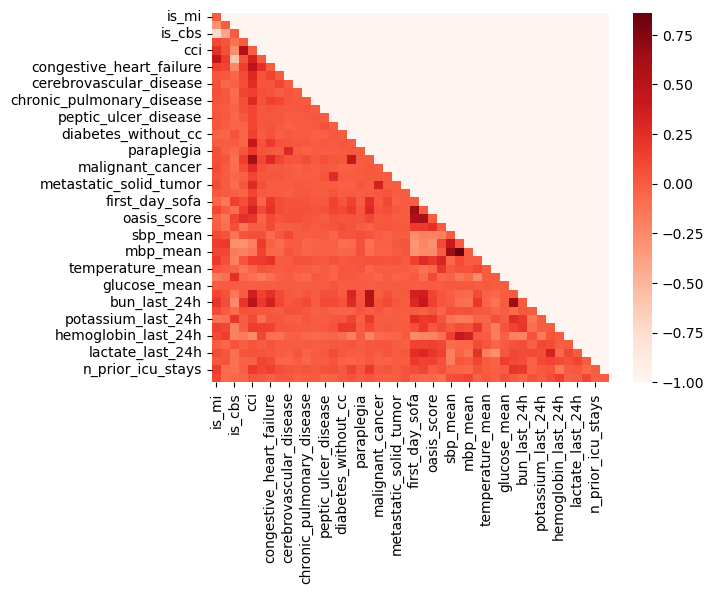

In [330]:
examine_corr(numerical_cols)

## Potential Multicollinearity? (comorb indicators == cci)

In [337]:
X_df_comorbs = X_df.loc[:, [col for col in binary_cols if "is_" not in col] + ['cci'] ]
X_df_comorbs

,myocardial_infarct,congestive_heart_failure,peripheral_vascular_disease,cerebrovascular_disease,dementia,chronic_pulmonary_disease,rheumatic_disease,peptic_ulcer_disease,mild_liver_disease,diabetes_without_cc,diabetes_with_cc,paraplegia,renal_disease,malignant_cancer,severe_liver_disease,metastatic_solid_tumor,aids,cci
0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,8
1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,6
2,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,8
3,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,8
4,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
15441,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
15442,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3
15443,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,8


In [340]:
X_df_comorbs.drop(columns=['cci']).sum(axis=1)

0        4
1        2
2        3
3        3
4        2
        ..
15440    0
15441    1
15442    1
15443    4
15444    4
Length: 15445, dtype: int64

In [343]:
X_df_comorbs.assign(is_cci_sum = X_df_comorbs['cci'] == X_df_comorbs.drop(columns=['cci']).sum(axis=1)).is_cci_sum.value_counts()

is_cci_sum
False    14660
True       785
Name: count, dtype: int64

# Clean entire dataset BUT DO NOT SPLIT -- JUST FOR EDA

In [259]:
import numpy as np
import pandas as pd

def _series_mode(s: pd.Series):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

def clean_df(
    merged_labeled: pd.DataFrame,
    y: pd.Series,
    numerical_cols: list,
    chi2_results: pd.DataFrame,
    cohort_col: str = "cohort",
    cramers_split: float = 0.4,
    clip_iqr: bool = False,
    iqr_factor: float = 1.5,
    clip_by_cohort: bool = False,
    drop_cols: list = ("prev_gap_days",),
    hard_outlier_rules: dict = None,
):
    """
    Returns (X_df_cleaned, y_cleaned)
    
    Pipeline:
      0) copy
      1) HARD row filters (drop rows based on explicit rules)
      2) optional IQR clipping (numeric, non-binary), global or per-cohort
      3) impute:
           - global median/mode if Cramér's V < cramers_split
           - cohort-wise median/mode if Cramér's V >= cramers_split
      4) drop `drop_cols`
    """

    # --- 0) copy
    X = merged_labeled.copy()
    y_in = y.copy()

    # --- 1) HARD OUTLIER FILTERS (row-wise)
    # default rules as per your note
    if hard_outlier_rules is None:
        hard_outlier_rules = {
            "glucose_mean": ("<", 999999),   # keep < 999999
            "wbc_last_24h": ("<", 400),      # keep < 400
        }

    keep_mask = pd.Series(True, index=X.index)
    for col, (op, val) in hard_outlier_rules.items():
        if col in X.columns:
            if op == "<":
                keep_mask &= (X[col] < val) | X[col].isna()
            elif op == "<=":
                keep_mask &= (X[col] <= val) | X[col].isna()
            elif op == ">":
                keep_mask &= (X[col] > val) | X[col].isna()
            elif op == ">=":
                keep_mask &= (X[col] >= val) | X[col].isna()
            elif op == "!=":
                keep_mask &= (X[col] != val) | X[col].isna()
            elif op == "==":
                keep_mask &= (X[col] == val) | X[col].isna()
            else:
                raise ValueError(f"Unsupported operator in hard_outlier_rules: {op}")

    X = X.loc[keep_mask].copy()
    y_out = y_in.loc[keep_mask].copy()

    # --- 2) OPTIONAL IQR CLIPPING (before imputation)
    if clip_iqr:
        # identify numeric non-binary columns actually present
        num_cols_present = [c for c in numerical_cols if c in X.columns]
        # drop near-binary numerics (2 unique non-null values)
        nonbinary_num = []
        for c in num_cols_present:
            nunq = X[c].dropna().nunique()
            if nunq > 2:
                nonbinary_num.append(c)

        def _clip_IQR(df, cols):
            for c in cols:
                x = df[c]
                # guard against constant or tiny samples
                q1 = x.quantile(0.25)
                q3 = x.quantile(0.75)
                iqr = q3 - q1
                if pd.isna(q1) or pd.isna(q3) or iqr == 0:
                    continue
                lo = q1 - iqr_factor * iqr
                hi = q3 + iqr_factor * iqr
                df[c] = x.clip(lower=lo, upper=hi)

        if clip_by_cohort and cohort_col in X.columns:
            for g, sub in X.groupby(cohort_col, dropna=False):
                idx = sub.index
                temp = sub[nonbinary_num].copy()
                _clip_IQR(temp, nonbinary_num)
                X.loc[idx, nonbinary_num] = temp
        else:
            _clip_IQR(X, nonbinary_num)

    # --- 3) IMPUTATION guided by Cramér’s V
    if "feature" not in chi2_results.columns or "cramers_v" not in chi2_results.columns:
        raise ValueError("chi2_results must have columns: ['feature','cramers_v'].")

    global_features = chi2_results.loc[chi2_results.cramers_v < cramers_split, "feature"]
    cohort_features = chi2_results.loc[chi2_results.cramers_v >= cramers_split, "feature"]

    # only keep features that exist in X
    global_features = [c for c in global_features if c in X.columns]
    cohort_features = [c for c in cohort_features if c in X.columns]

    num_set = set([c for c in numerical_cols if c in X.columns])

    # global impute
    for col in global_features:
        if col in drop_cols: 
            continue
        if col in num_set:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(_series_mode(X[col]))

    # cohort-wise impute
    if cohort_col in X.columns and len(X[cohort_col].dropna().unique()) > 0:
        for col in cohort_features:
            if col in drop_cols:
                continue
            if col in num_set:
                X[col] = X.groupby(cohort_col, group_keys=False)[col].apply(
                    lambda s: s.fillna(s.median())
                )
            else:
                # fill with cohort mode; fallback to global mode if empty
                def fill_mode(s):
                    m = s.mode(dropna=True)
                    fallback = _series_mode(X[col])
                    return s.fillna(m.iloc[0] if len(m) else fallback)
                X[col] = X.groupby(cohort_col, group_keys=False)[col].apply(fill_mode)
    else:
        # no cohort info -> treat all as global
        for col in cohort_features:
            if col in drop_cols:
                continue
            if col in num_set:
                X[col] = X[col].fillna(X[col].median())
            else:
                X[col] = X[col].fillna(_series_mode(X[col]))

    # --- 4) DROP requested columns (e.g., prev_gap_days)
    cols_to_drop = [c for c in drop_cols if c in X.columns]
    if cols_to_drop:
        X = X.drop(columns=cols_to_drop)

    return X, y_out


Inspect cleaned dataset

In [260]:
X_clean_basic, y_clean_basic = clean_df(
    merged_labeled=merged_labeled,
    y=y,
    numerical_cols=numerical_cols,
    chi2_results=chi2_results,
    cohort_col="cohort",      # the categorical column identifying MI / PCI / CABG
    cramers_split=0.4,        # threshold for global vs cohort-wise imputation
    clip_iqr=False,           # disable IQR clipping
)


X_clean_iqr_global, y_clean_iqr_global = clean_df(
    merged_labeled=merged_labeled,
    y=y,
    numerical_cols=numerical_cols,
    chi2_results=chi2_results,
    cohort_col="cohort",
    cramers_split=0.4,
    clip_iqr=True,            # enable clipping
    iqr_factor=1.5,           # standard Tukey rule
    clip_by_cohort=False      # global thresholds for all patients combined
)


In [288]:
X_clean_iqr_global

,subject_id,hadm_id,stay_id,is_mi,is_pcr,is_cbs,age,gender,race,admission_type,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort
0,10154719,21914168,35702330,1,0,0,68,M,WHITE,EW EMER.,...,12.0,141.0,3.2,136.0,13.4,12.4,1.6,1.030,1,MI
1,10949596,26086151,31406916,1,0,0,79,M,WHITE,URGENT,...,14.0,130.0,3.6,99.0,11.2,12.2,1.6,1.500,0,MI
2,11038900,29967401,30447128,1,0,0,76,M,UNKNOWN,URGENT,...,22.0,135.0,3.9,204.0,7.7,11.1,1.4,0.370,0,MI
3,11038900,29967401,33744055,1,0,0,76,M,UNKNOWN,URGENT,...,16.0,133.0,4.1,189.0,8.2,11.6,1.6,2.830,1,MI
4,11384756,21111442,31242950,1,0,0,61,F,WHITE,SURGICAL SAME DAY ADMISSION,...,17.0,134.0,4.1,119.0,10.7,10.4,0.8,1.500,0,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,1,65,M,WHITE,URGENT,...,13.0,135.0,4.4,95.0,13.3,12.8,1.6,0.715,0,CABG
15441,19995780,21942461,36805359,0,0,1,84,M,WHITE,EW EMER.,...,11.0,134.0,5.0,145.0,11.2,14.9,1.6,0.715,0,CABG
15442,19995790,22970553,34995866,0,0,1,66,M,WHITE,SURGICAL SAME DAY ADMISSION,...,18.0,133.0,4.4,126.0,10.9,10.9,2.3,0.715,0,CABG
15443,19996673,29017569,38026904,0,0,1,72,F,WHITE,URGENT,...,38.0,135.0,5.4,109.0,8.4,9.8,1.8,2.270,0,CABG


In [294]:
numerical_cols

['is_mi',
 'is_pcr',
 'is_cbs',
 'age',
 'cci',
 'myocardial_infarct',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'cerebrovascular_disease',
 'dementia',
 'chronic_pulmonary_disease',
 'rheumatic_disease',
 'peptic_ulcer_disease',
 'mild_liver_disease',
 'diabetes_without_cc',
 'diabetes_with_cc',
 'paraplegia',
 'renal_disease',
 'malignant_cancer',
 'severe_liver_disease',
 'metastatic_solid_tumor',
 'aids',
 'first_day_sofa',
 'apsiii_score',
 'oasis_score',
 'heart_rate_mean',
 'sbp_mean',
 'dbp_mean',
 'mbp_mean',
 'resp_rate_mean',
 'temperature_mean',
 'spo2_mean',
 'glucose_mean',
 'creatinine_last_24h',
 'bun_last_24h',
 'sodium_last_24h',
 'potassium_last_24h',
 'glucose_last_24h',
 'hemoglobin_last_24h',
 'wbc_last_24h',
 'lactate_last_24h',
 'troponin_last_24h',
 'n_prior_icu_stays',
 'prev_gap_days']

In [305]:
# prev_gap_days is excluded
non_binary_numerical_cols = ["glucose_mean", "glucose_last_24h", "wbc_last_24h", "bun_last_24h", "apsiii_score", "sbp_mean", "mbp_mean", "heart_rate_mean", "dbp_mean", "troponin_last_24h",
 "oasis_score", "lactate_last_24h", "age", "n_prior_icu_stays", "creatinine_last_24h", "first_day_sofa", "resp_rate_mean", "cci", "hemoglobin_last_24h", "potassium_last_24h", "temperature_mean", "spo2_mean"]

In [261]:
# X_clean_basic.to_csv("X_clean_basic.csv")
# y_clean_basic.to_csv("y_clean_basic.csv")
# X_clean_iqr_global.to_csv("X_clean_iqr_global.csv")
# y_clean_iqr_global.to_csv("y_clean_iqr_global.csv")

In [298]:
# original dataset has 15445 rows and there are only 3 outliers, so nothing wrong with clean_df(),
X_clean_basic.shape[0], X_clean_iqr_global.shape[0] 

(15442, 15442)

In [264]:
# plot_feature_boxplots(
#     X_clean_iqr_global,
#     ["troponin_last_24h", "lactate_last_24h", "glucose_mean"],
#     cohort_col="gender",
#     group_by_cohort=True,
#     cohorts_order=sorted(X_clean_iqr_global["gender"].dropna().unique()),
#     cols=3,
#     clip_quantiles=(0.01, 0.99),
#     title="First-day labs by gender"
# )

In [299]:
summ_stats_and_NA_per_column(X_clean_basic, y_keep, col=None, sort_by_na_vals=False)

Summary statistics (whole dataset)


,count,mean,std,min,25%,50%,75%,max,skewness,diff_max_3rd_quartile,na_vals,na_prop
glucose_mean,15442.0,154.0,690.5,51.0,120.3,131.7,151.4,52747.6,2.4,52596.2,0.0,0.0
glucose_last_24h,15442.0,133.6,57.2,0.1,104.0,120.0,143.0,1000.0,2.8,857.0,0.0,0.0
wbc_last_24h,15442.0,12.3,7.0,0.0,8.8,11.4,14.5,292.5,2.8,278.0,0.0,0.0
bun_last_24h,15442.0,23.3,17.3,2.0,13.0,18.0,26.0,198.0,2.8,172.0,0.0,0.0
apsiii_score,15442.0,40.5,19.7,3.0,27.0,36.0,48.0,164.0,2.8,116.0,0.0,0.0
sbp_mean,15442.0,113.6,12.7,34.2,105.6,112.1,119.7,215.9,2.8,96.1,0.0,0.0
mbp_mean,15442.0,76.3,9.0,29.0,70.6,75.1,80.6,159.5,2.8,78.9,0.0,0.0
heart_rate_mean,15442.0,81.1,12.4,33.5,73.2,80.4,88.2,162.4,2.8,74.3,0.0,0.0
dbp_mean,15442.0,60.3,9.7,20.8,53.9,59.1,65.5,136.0,2.8,70.5,0.0,0.0
troponin_last_24h,15442.0,1.7,2.6,0.0,0.7,0.7,1.5,51.8,2.8,50.3,0.0,0.0


--------------------------------------------------
Class distribution (whole dataset)


,count,proportion
y,,
0,14529,0.940876
1,913,0.059124


In [307]:
X_df[X_df.n_prior_icu_stays == 0].prev_gap_days.unique()

array([nan])

# What have we learned from EDA & Preprocessing AFTER train/val/test split
1. Outlier (define as **extreme measurement noise/physiologically implausible measurements**)
- Remove 1 CABG case with `glucose_mean=999999` as it is almost certainly a placeholder instead of a genuine measurement
- Remove 2 MI cases with abnormally high `wbc_last_24h` (above 400 billion per liter)
- **Leave other features unchanged -- removing outliers should always have a clinical justification. BUT REMEMBER TO STANDARDIZE INPUTS BEFORE FEEDING THEM INTO ML MODELS**


2. Since `prev_gap_days` is **not** missing completely at random/not missing at random, We decided to drop it (and only use `n_prior_icu_stays` for prior treatment information) because it has 83% missing values (12776 out of 155445 are missing)

3. **We might wanna consider clipping univariate features to `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`** since `max(glucose_mean)` is still `52747.6`. Argue that it is actionable since we do not know exactly whether these are genuine patient variations or not.


3. Imputation (simple). In the training data, use median for global numeric imputation (|skewness| > 1.8 in EDA) and mode for categorical imputation 





Imputation (future work). For split aware, only compute on training data
- Compute Cramér’s V between cohort and the missingness indicator for each variable.
- If Cramér’s V ≤ 0.2 → Missingness pattern shows weak association with cohort → use global imputation (pooled distribution).
- If Cramér’s V ≥ 0.5 → Strong cohort dependence → use within-cohort imputation (separately per CABG, MI, PCI).

# Splitting

## Consider including race in the strata

In [268]:
merged_labeled

,subject_id,hadm_id,stay_id,is_mi,is_pcr,is_cbs,age,gender,race,admission_type,...,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days,cohort
0,10154719,21914168,35702330,1,0,0,68,M,WHITE,EW EMER.,...,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,1014.000000,MI
1,10949596,26086151,31406916,1,0,0,79,M,WHITE,URGENT,...,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,NaN,MI
2,11038900,29967401,30447128,1,0,0,76,M,UNKNOWN,URGENT,...,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,NaN,MI
3,11038900,29967401,33744055,1,0,0,76,M,UNKNOWN,URGENT,...,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,1.666667,MI
4,11384756,21111442,31242950,1,0,0,61,F,WHITE,SURGICAL SAME DAY ADMISSION,...,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,NaN,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,1,65,M,WHITE,URGENT,...,135.0,4.4,95.0,13.3,12.8,1.6,NaN,0,NaN,CABG
15441,19995780,21942461,36805359,0,0,1,84,M,WHITE,EW EMER.,...,134.0,5.0,145.0,11.2,14.9,1.6,NaN,0,NaN,CABG
15442,19995790,22970553,34995866,0,0,1,66,M,WHITE,SURGICAL SAME DAY ADMISSION,...,133.0,4.4,126.0,10.9,10.9,2.3,NaN,0,NaN,CABG
15443,19996673,29017569,38026904,0,0,1,72,F,WHITE,URGENT,...,135.0,5.4,109.0,8.4,9.8,NaN,2.27,0,NaN,CABG


In [275]:
sorted(merged_labeled.race.unique())

['AMERICAN INDIAN/ALASKA NATIVE',
 'ASIAN',
 'ASIAN - ASIAN INDIAN',
 'ASIAN - CHINESE',
 'ASIAN - KOREAN',
 'ASIAN - SOUTH EAST ASIAN',
 'BLACK/AFRICAN',
 'BLACK/AFRICAN AMERICAN',
 'BLACK/CAPE VERDEAN',
 'BLACK/CARIBBEAN ISLAND',
 'HISPANIC OR LATINO',
 'HISPANIC/LATINO - CENTRAL AMERICAN',
 'HISPANIC/LATINO - COLUMBIAN',
 'HISPANIC/LATINO - CUBAN',
 'HISPANIC/LATINO - DOMINICAN',
 'HISPANIC/LATINO - GUATEMALAN',
 'HISPANIC/LATINO - HONDURAN',
 'HISPANIC/LATINO - MEXICAN',
 'HISPANIC/LATINO - PUERTO RICAN',
 'HISPANIC/LATINO - SALVADORAN',
 'MULTIPLE RACE/ETHNICITY',
 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER',
 'OTHER',
 'PATIENT DECLINED TO ANSWER',
 'PORTUGUESE',
 'SOUTH AMERICAN',
 'UNABLE TO OBTAIN',
 'UNKNOWN',
 'WHITE',
 'WHITE - BRAZILIAN',
 'WHITE - EASTERN EUROPEAN',
 'WHITE - OTHER EUROPEAN',
 'WHITE - RUSSIAN']

In [285]:
(merged_labeled.assign(joint_cohort = merged_labeled.race + '-' + merged_labeled.cohort).joint_cohort.value_counts() < 3).sort_values(ascending=False).head(15)

joint_cohort
ASIAN - KOREAN-PCI                        True
MULTIPLE RACE/ETHNICITY-PCI               True
HISPANIC/LATINO - MEXICAN-MI              True
HISPANIC/LATINO - HONDURAN-MI             True
SOUTH AMERICAN-MI                         True
ASIAN - KOREAN-MI                         True
HISPANIC/LATINO - HONDURAN-PCI            True
HISPANIC/LATINO - COLUMBIAN-PCI           True
PORTUGUESE-PCI                            True
WHITE - BRAZILIAN-PCI                     True
HISPANIC/LATINO - CUBAN-PCI               True
HISPANIC/LATINO - CENTRAL AMERICAN-PCI    True
HISPANIC/LATINO - CENTRAL AMERICAN-MI     True
HISPANIC/LATINO - SALVADORAN-MI           True
HISPANIC/LATINO - MEXICAN-PCI             True
Name: count, dtype: bool

In [272]:
merged_labeled.assign(joint_cohort = merged_labeled.gender + '-' + merged_labeled.cohort).joint_cohort.value_counts()

joint_cohort
M-CABG    5919
M-MI      3582
F-MI      1848
F-CABG    1747
M-PCI     1501
F-PCI      848
Name: count, dtype: int64

## The function

In [376]:
# Convert one-hot cohort flags into a single label
def label_subcohort(df):
    df = df.copy()
    df["cohort"] = np.select(
        [
            df["is_mi"] == 1,
            df["is_pcr"] == 1,
            df["is_cbs"] == 1
        ],
        ["MI", "PCI", "CABG"],
        default="Other"
    )
    return df

# 1) collapse race to a few stable bins
def collapse_race(r):
    if pd.isna(r): return "UNKNOWN/OTHER"
    r = str(r).upper()
    if r.startswith("WHITE"): return "WHITE"
    if r.startswith("BLACK"): return "BLACK"
    if r.startswith("ASIAN"): return "ASIAN"
    if "HISPANIC" in r:        return "HISPANIC"
    if "PORTUGUESE" in r:      return "PORTUGUESE"
    if "SOUTH AMERICAN" in r:  return "HISPANIC"  # sensible merge
    if "PACIFIC ISLANDER" in r:return "PACIFIC"
    if r in {"OTHER","UNKNOWN","UNABLE TO OBTAIN","PATIENT DECLINED TO ANSWER",
             "MULTIPLE RACE/ETHNICITY","AMERICAN INDIAN/ALASKA NATIVE",
             "WHITE - OTHER EUROPEAN","WHITE - EASTERN EUROPEAN","WHITE - RUSSIAN",
             "WHITE - BRAZILIAN","BLACK/CAPE VERDEAN","BLACK/CARIBBEAN ISLAND"}:
        return "UNKNOWN/OTHER"
    return "UNKNOWN/OTHER"

def build_subject_strata(df: pd.DataFrame,
                         min_bin_size: int = 5,
                         outcome_col: str = "y",
                         cohort_col: str = "cohort",
                         race_col: str = "race"):
    
    g = df.copy()

    if "cohort" not in g.columns:
        g = label_subcohort(g)
    
    g["race_collapsed"] = g[race_col].map(collapse_race)

    # Make a *stable* per-subject cohort label.
    # Option A: majority cohort across their stays
    subj_mode_cohort = (
        g.groupby(["subject_id", cohort_col]).size()
         .reset_index(name="n")
         .sort_values(["subject_id","n"], ascending=[True, False])
         .drop_duplicates("subject_id")[["subject_id", cohort_col]]
         .rename(columns={cohort_col: "cohort_major"})
    )

    # Outcome as a subject-level flag (any positive stay)
    subj_y = (
        g.groupby("subject_id")[outcome_col]
         .max()
         .rename("y_any")
         .reset_index()
    )

    # Subject-level collapsed race: mode
    subj_race = (
        g.groupby(["subject_id","race_collapsed"]).size()
         .reset_index(name="n")
         .sort_values(["subject_id","n"], ascending=[True, False])
         .drop_duplicates("subject_id")[["subject_id","race_collapsed"]]
    )

    subj = (
        subj_mode_cohort.merge(subj_race, on="subject_id")
                        .merge(subj_y, on="subject_id")
    )

    # Compose strata label; you can add age bands, etc., if you want more control
    subj["strata"] = (
        subj["cohort_major"].astype(str) + "|" +
        subj["race_collapsed"].astype(str) + "|" +
        subj["y_any"].astype(str)
    )

    # Merge rare strata into a single bin to avoid stratify errors
    counts = subj["strata"].value_counts()
    rare = counts[counts < min_bin_size].index
    subj.loc[subj["strata"].isin(rare), "strata"] = "OTHER_BIN"

    return subj[["subject_id","strata"]]

def remove_outlier_drop_gapdays_and_split(df_all: pd.DataFrame,
                                          val_and_test_size: float = 0.30,
                                          random_state: int = 42,
                                          outcome_col: str = "y",
                                          cohort_col: str = "cohort",
                                          race_col: str = "race"):
    """
    - Hard-remove obvious data-entry outliers.
    - Drop prev_gap_days (non-imputable by design).
    - Stratified split by *subject_id* using a patient-level strata label
      (cohort_major × collapsed race × y_any), with rare bins merged.
    - Returns row-level train/val/test DataFrames.
    """
    # 0) hard outliers + drop prev_gap_days
    df = df_all.copy()
    df = df[(df["glucose_mean"] < 999999) & (df["wbc_last_24h"] < 400)]
    if "prev_gap_days" in df.columns:
        df = df.drop(columns=["prev_gap_days"])

    # 1) build subject-level strata
    subj = build_subject_strata(df, min_bin_size=5,
                                outcome_col=outcome_col,
                                cohort_col=cohort_col,
                                race_col=race_col)

    # 2) split BY subject IDs into train vs temp (val+test) with stratify
    train_ids, temp_ids = train_test_split(
        subj["subject_id"].values,
        test_size=val_and_test_size,
        random_state=random_state,
        stratify=subj["strata"].values
    )

    # 3) from the temp pool, split val vs test (50/50) with stratify again
    temp = subj[subj["subject_id"].isin(temp_ids)]
    val_ids, test_ids = train_test_split(
        temp["subject_id"].values,
        test_size=0.5,
        random_state=random_state,
        stratify=temp["strata"].values
    )

    # 4) map IDs back to rows
    train_df = df[df["subject_id"].isin(train_ids)].copy()
    val_df   = df[df["subject_id"].isin(val_ids)].copy()
    test_df  = df[df["subject_id"].isin(test_ids)].copy()

    # Optional sanity checks
    for s in ["train","val","test"]:
        print(s, df[df.subject_id.isin(eval(f"{s}_ids"))][outcome_col].mean())

    return train_df, val_df, test_df


In [413]:
def examine_splits(df, df_type='train'):
    print('-'*25, f'EXAMINING {df_type} data', '-'*25)
    print(f'{df_type} data has {df.shape[0]} ICU stays across {df.subject_id.nunique()} patients.')
    print('-'*25, 'EXAMINE FIRST FEW INSTANCES', '-'*25)
    display(df.head())
    
    print('-'*25, 'CLASS DISTRIBUTION (%)', '-'*25)
    display(df.y.value_counts(normalize=True)*100)
    
    print('-'*25, f'RACE DISTRIBUTION (%) ({df.race.nunique()} races)', '-'*25)
    display(df.race.value_counts(normalize=True)*100)
    
    print('-'*25, 'COHORT DISTRIBUTION (%)', '-'*25)
    display(df.cohort.value_counts(normalize=True)*100)
    
    print('-'*25, 'AGE DISTRIBUTION', '-'*25)
    df.hist('age')

In [486]:
train_df, val_df, test_df = remove_outlier_drop_gapdays_and_split(
    pd.concat([merged_labeled, y], axis=1),
    val_and_test_size = 0.3,
    random_state=42,
    outcome_col='y',
    cohort_col='cohort',
    race_col='race'
)

train 0.058043273753527753
val 0.06519823788546256
test 0.05415002219263205


------------------------- EXAMINING train data -------------------------
train data has 10630 ICU stays across 7732 patients.
------------------------- EXAMINE FIRST FEW INSTANCES -------------------------


,subject_id,hadm_id,stay_id,is_mi,is_pcr,is_cbs,age,gender,race,admission_type,...,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort,y
1,10949596,26086151,31406916,1,0,0,79,M,WHITE,URGENT,...,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,MI,0
4,11384756,21111442,31242950,1,0,0,61,F,WHITE,SURGICAL SAME DAY ADMISSION,...,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,MI,0
5,11435126,21380778,31884823,1,0,0,55,M,WHITE,EW EMER.,...,140.0,3.6,160.0,13.1,11.0,NaN,0.59,0,MI,1
6,11441864,22241075,34061358,1,0,0,78,M,WHITE,ELECTIVE,...,140.0,3.5,119.0,9.3,8.5,1.1,NaN,0,MI,0
7,11681010,23407541,39279281,1,0,0,83,M,ASIAN,DIRECT EMER.,...,134.0,4.7,247.0,13.4,15.4,2.6,2.92,0,MI,1


------------------------- CLASS DISTRIBUTION (%) -------------------------


y
0    94.195673
1     5.804327
Name: proportion, dtype: float64

------------------------- RACE DISTRIBUTION (%) (33 races) -------------------------


race
WHITE                                        63.838194
UNKNOWN                                      13.000941
BLACK/AFRICAN AMERICAN                        4.553151
UNABLE TO OBTAIN                              3.283161
OTHER                                         2.944497
WHITE - OTHER EUROPEAN                        2.539981
WHITE - RUSSIAN                               1.288805
PATIENT DECLINED TO ANSWER                    1.006585
HISPANIC/LATINO - PUERTO RICAN                0.959548
ASIAN                                         0.940734
HISPANIC/LATINO - DOMINICAN                   0.780809
ASIAN - CHINESE                               0.743180
HISPANIC OR LATINO                            0.526811
WHITE - EASTERN EUROPEAN                      0.385701
ASIAN - ASIAN INDIAN                          0.385701
BLACK/CARIBBEAN ISLAND                        0.376294
ASIAN - SOUTH EAST ASIAN                      0.348071
BLACK/CAPE VERDEAN                            0.348071
PORTU

------------------------- COHORT DISTRIBUTION (%) -------------------------


cohort
CABG    50.225776
MI      34.684854
PCI     15.089370
Name: proportion, dtype: float64

------------------------- AGE DISTRIBUTION -------------------------


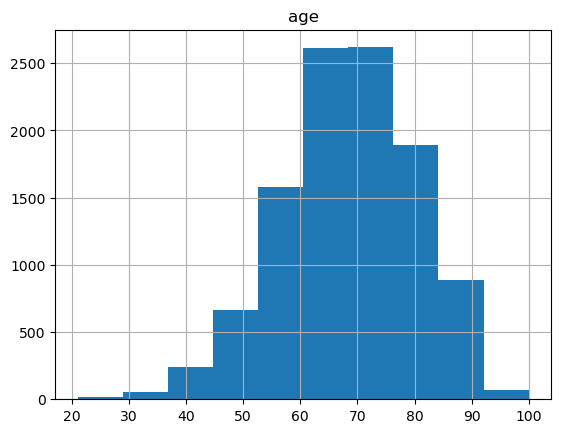

In [415]:
examine_splits(train_df, df_type='train')

------------------------- EXAMINING val data -------------------------
val data has 2270 ICU stays across 1657 patients.
------------------------- EXAMINE FIRST FEW INSTANCES -------------------------


,subject_id,hadm_id,stay_id,is_mi,is_pcr,is_cbs,age,gender,race,admission_type,...,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort,y
2,11038900,29967401,30447128,1,0,0,76,M,UNKNOWN,URGENT,...,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,MI,1
3,11038900,29967401,33744055,1,0,0,76,M,UNKNOWN,URGENT,...,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,MI,0
19,14139649,28669544,37348855,1,0,0,62,M,WHITE,OBSERVATION ADMIT,...,133.0,3.9,141.0,10.5,11.8,1.4,0.76,0,MI,1
24,14780705,22537634,35135206,1,0,0,70,M,WHITE,EW EMER.,...,136.0,4.2,129.0,14.9,7.5,2.0,NaN,2,MI,0
39,17215783,27770924,34346453,1,0,0,68,M,OTHER,DIRECT EMER.,...,138.0,4.1,169.0,7.6,0.5,3.9,0.47,0,MI,0


------------------------- CLASS DISTRIBUTION (%) -------------------------


y
0    93.480176
1     6.519824
Name: proportion, dtype: float64

------------------------- RACE DISTRIBUTION (%) (30 races) -------------------------


race
WHITE                                        63.656388
UNKNOWN                                      12.378855
OTHER                                         4.317181
BLACK/AFRICAN AMERICAN                        4.052863
UNABLE TO OBTAIN                              3.039648
WHITE - OTHER EUROPEAN                        2.863436
HISPANIC/LATINO - PUERTO RICAN                1.497797
WHITE - RUSSIAN                               1.233480
PATIENT DECLINED TO ANSWER                    0.969163
ASIAN                                         0.925110
HISPANIC OR LATINO                            0.616740
HISPANIC/LATINO - DOMINICAN                   0.572687
ASIAN - ASIAN INDIAN                          0.484581
BLACK/CAPE VERDEAN                            0.440529
BLACK/CARIBBEAN ISLAND                        0.440529
HISPANIC/LATINO - GUATEMALAN                  0.352423
WHITE - EASTERN EUROPEAN                      0.352423
ASIAN - SOUTH EAST ASIAN                      0.352423
BLACK

------------------------- COHORT DISTRIBUTION (%) -------------------------


cohort
CABG    50.660793
MI      34.801762
PCI     14.537445
Name: proportion, dtype: float64

------------------------- AGE DISTRIBUTION -------------------------


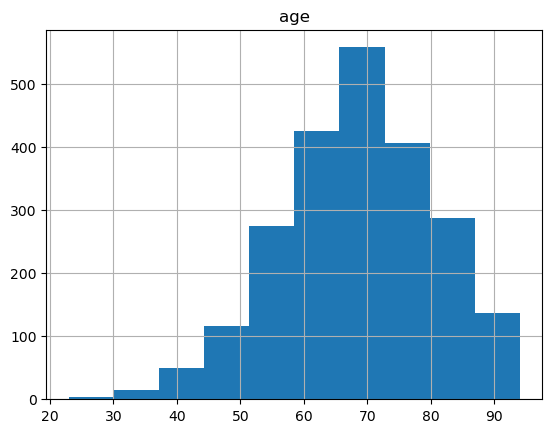

In [416]:
examine_splits(val_df, df_type='val')

------------------------- EXAMINING test data -------------------------
test data has 2253 ICU stays across 1657 patients.
------------------------- EXAMINE FIRST FEW INSTANCES -------------------------


,subject_id,hadm_id,stay_id,is_mi,is_pcr,is_cbs,age,gender,race,admission_type,...,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort,y
0,10154719,21914168,35702330,1,0,0,68,M,WHITE,EW EMER.,...,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,MI,0
14,13678189,20731516,33368602,1,0,0,61,M,WHITE,OBSERVATION ADMIT,...,147.0,3.4,294.0,10.2,5.1,1.5,1.03,0,MI,0
26,15156174,27579747,33046466,1,0,0,51,M,WHITE,URGENT,...,142.0,4.3,107.0,11.7,6.4,NaN,1.14,1,MI,0
37,17031608,23375584,39314937,1,0,0,82,F,WHITE,EW EMER.,...,143.0,4.2,113.0,10.3,7.1,NaN,0.48,0,MI,0
40,17579498,21787496,30038282,1,0,0,82,M,WHITE,URGENT,...,137.0,3.8,110.0,11.3,8.7,NaN,1.49,0,MI,0


------------------------- CLASS DISTRIBUTION (%) -------------------------


y
0    94.584998
1     5.415002
Name: proportion, dtype: float64

------------------------- RACE DISTRIBUTION (%) (29 races) -------------------------


race
WHITE                                        65.113182
UNKNOWN                                      12.516644
BLACK/AFRICAN AMERICAN                        4.305371
UNABLE TO OBTAIN                              2.885042
OTHER                                         2.751886
WHITE - OTHER EUROPEAN                        2.441190
PATIENT DECLINED TO ANSWER                    1.464714
WHITE - RUSSIAN                               1.420328
HISPANIC/LATINO - PUERTO RICAN                0.932091
ASIAN                                         0.932091
HISPANIC/LATINO - DOMINICAN                   0.621394
HISPANIC OR LATINO                            0.488238
WHITE - EASTERN EUROPEAN                      0.443853
ASIAN - CHINESE                               0.443853
BLACK/CAPE VERDEAN                            0.399467
BLACK/CARIBBEAN ISLAND                        0.355082
BLACK/AFRICAN                                 0.310697
ASIAN - ASIAN INDIAN                          0.266312
ASIAN

------------------------- COHORT DISTRIBUTION (%) -------------------------


cohort
CABG    50.510431
MI      34.576121
PCI     14.913449
Name: proportion, dtype: float64

------------------------- AGE DISTRIBUTION -------------------------


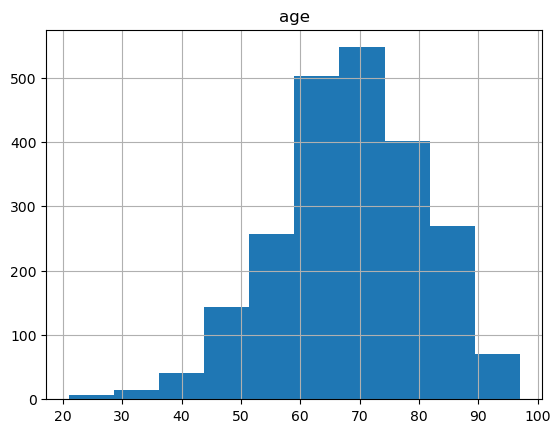

In [417]:
examine_splits(test_df, df_type='test')

# Define a custom `MedianModeImputer`.

What we do now.
1. Compute medians for numeric variables and modes for categorical variables.
2. Impute missing numeric vals in val/test using medians, and missing categories using modes.


Future work (implementation too complex, risk missing cohort labels in training and testing).

1. After our train/val/test split, run the Cramér’s V / χ² association only on the training set (`fit_transform` for training, `transform` only for val/test) between:
- `M_col` = binary indicator of missingness for feature `col`
- `cohort` (in fact *any* variable can be set as a grouping e.g. gender, age band, etc)

2. Imputation in training set 
- If `V < t` → **global** imputation for that feature (median/mode from train).
- If `V ≥ t` → **cohort-wise** imputation (compute medians/modes within train cohorts).
- (Optional) Middle region → default to global, or cohort-wise only if N per cohort is adequate.

In [461]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# BaseEstimator: sklearn mixin that makes the class compatible with sklearn API (e.g. get_params, set_params etc)
# TransformerMixin: adds a default fit_transform implementation (provided .fit() and .transform() are already defined)
class MedianModeImputer(BaseEstimator, TransformerMixin):
    """
    - Clips numeric cols by IQR (optional).
    - Imputes numeric with median.
    - Imputes categorical with mode; if a column has no non-null values in train,
      falls back to a constant 'UNK' (you can change this).
    """
    def __init__(self, numeric_cols, categorical_cols, clip_iqr=False, iqr_factor=1.5, cat_fallback="UNK"):
        self.numeric_cols = list(numeric_cols) if numeric_cols is not None else []
        self.categorical_cols = list(categorical_cols) if categorical_cols is not None else []
        self.clip_iqr = clip_iqr
        self.iqr_factor = iqr_factor
        self.cat_fallback = cat_fallback

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        # Medians for numerics (handle empty list)
        if self.numeric_cols:
            self.medians_ = X[self.numeric_cols].median()
            if self.clip_iqr:
                Q1 = X[self.numeric_cols].quantile(0.25)
                Q3 = X[self.numeric_cols].quantile(0.75)
                IQR = Q3 - Q1
                self.lower_ = Q1 - self.iqr_factor * IQR
                self.upper_ = Q3 + self.iqr_factor * IQR
        else:
            self.medians_ = pd.Series(dtype=float)
            self.lower_ = pd.Series(dtype=float)
            self.upper_ = pd.Series(dtype=float)

        # Modes for categoricals (robust to “no mode”)
        modes = {}
        for col in self.categorical_cols:
            s = X[col] if col in X.columns else pd.Series([])
            s_nonnull = s.dropna()
            if len(s_nonnull) == 0:
                modes[col] = self.cat_fallback
            else:
                m = s_nonnull.mode()
                modes[col] = m.iloc[0] if len(m) else self.cat_fallback
        self.modes_ = pd.Series(modes, dtype="object")

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        # Clip numerics if requested
        for col in self.numeric_cols:
            if self.clip_iqr and col in X.columns and col in self.lower_.index:
                X[col] = X[col].clip(self.lower_[col], self.upper_[col])

        # Impute numerics
        for col in self.numeric_cols:
            if col in X.columns and col in self.medians_.index:
                X[col] = X[col].fillna(self.medians_[col])

        # Impute categoricals
        for col in self.categorical_cols:
            if col in X.columns and col in self.modes_.index:
                X[col] = X[col].fillna(self.modes_[col])

        return X


In [286]:
# # BaseEstimator: sklearn mixin that makes the class compatible with sklearn API (e.g. get_params, set_params etc)
# # TransformerMixin: adds a default fit_transform implementation (provided .fit() and .transform() are already defined)
# class MedianModeImputer(BaseEstimator, TransformerMixin):

#     # constructor: define the Imputer.
#     # in sklearn it should only assign arguments to attributes
#     def __init__(self, num_cols, cat_cols, cohort_col=None,
#                  v_threshold=0.4, use_cramers_rule=False):
#         self.num_cols = list(num_cols)
#         self.cat_cols = list(cat_cols)
#         self.cohort_col = cohort_col
#         self.v_threshold = v_threshold
#         self.use_cramers_rule = use_cramers_rule

#     # learns parameters from training data (e.g. medians, modes) and stores them as attributes e.g. self.medians_
#     def fit(self, X, y=None):

#         """
#         learns parameters from training data (e.g. medians, modes) and stores them as attributes
#         in a dictionary
#         """
        
#         X = X.copy()

        
#         self.global_stats_ = {} # {feature: aggregated statistic}, if feature's NA indicators are indep of cohort_col values
#         self.cohort_stats_ = {} # {feature: aggregated statistics GROUPED BY cohort_col}, if feature's NA indicators are NOT indep of cohort_col values
#         self.strategy_map_ = {}  # feature -> "global" or "cohort"

#         # Obtain pd.Series of cohort categories on train (e.g. ["MI","MI", "CBS", ....])
#         cohorts = None
#         if self.use_cramers_rule and self.cohort_col is not None:
#             cohorts = X[self.cohort_col].astype('category')

#         # construct frequency table of binary NA indicators "miss" and the cohort values "cohort_series",
#         # conduct a chi2 test of association and record Cramer's V effect size (b/w 0,1)
#         def cramers_v(miss, cohort_series):
#             # miss: boolean Series; cohort: categorical Series
#             tbl = pd.crosstab(miss, cohort_series, dropna=False)
#             chi2, p, dof, _ = scipy.stats.chi2_contingency(tbl, correction=False)
#             n = tbl.values.sum()
#             if n == 0:
#                 return 0.0
#             phi2 = chi2 / n
#             r, k = tbl.shape
#             # Bias correction (Bergsma 2013)
#             phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
#             rcorr = r - ((r-1)**2)/(n-1)
#             kcorr = k - ((k-1)**2)/(n-1)
#             return np.sqrt(phi2corr / max(1e-12, min(kcorr-1, rcorr-1)))

#         # per feature, decide strategy and compute stats from TRAIN ONLY (i.e. make sure X here is training)
#         for col in self.num_cols + self.cat_cols:
            
#             miss = X[col].isna()
#             use_cohort = False

#             # 0. if we wanna consider witihin-cohort_col imputation, compute a cramer's V statistic
#             # of this col's missingness to cohort_col. Use within-cohort is use_cohort=True, o/w use_cohort=False and global is used
#             if self.use_cramers_rule and self.cohort_col is not None and miss.any():
#                 v = cramers_v(miss, cohorts)
#                 use_cohort = bool(v >= self.v_threshold)

#             # 1. if strategy is to use cohort-based imputation, store NOT a single median/mode BUT means/modes GROUPED BY cohort_col
#             if use_cohort:
#                 self.strategy_map_[col] = "cohort"
                
#                 # per-cohort stats
#                 if col in self.num_cols:
#                     self.cohort_stats_[col] = X.groupby(self.cohort_col)[col].median()
#                 else:
#                     self.cohort_stats_[col] = X.groupby(self.cohort_col)[col].agg(lambda s: s.mode(dropna=True).iloc[0] if s.notna().any() else np.nan)
                    
#             # 2. if strategy is global, simply store the aggregated statistic for the 
#             else:
#                 self.strategy_map_[col] = "global"
                
#                 if col in self.num_cols:
#                     self.global_stats_[col] = X[col].median()
#                 else:
#                     self.global_stats_[col] = X[col].mode(dropna=True).iloc[0] if X[col].notna().any() else np.nan

#         return self

#     def transform(self, X):

#         """
#         Given estimates global_stats and cohort_stats (median and means) estimated from some training data
#         during .fit(X_train), 'transform' val/test data X using the estimates
#         """
        
#         X = X.copy()
#         # Global imputes (from global_stats: {feature: median/mode})
#         for col, val in self.global_stats_.items():
#             X[col] = X[col].fillna(val)

#         # Cohort-wise imputes (from cohort_stats {feature: median/modes grouped by cohort_col}
#         if self.cohort_stats_:
#             for col, ser in self.cohort_stats_.items():
                
#                 if self.cohort_col not in X:
#                     # fallback if cohort column missing at inference
#                     fallback = self.global_stats_.get(col, np.nan)
#                     X[col] = X[col].fillna(fallback)
#                     continue
                    
#                 X[col] = X.groupby(self.cohort_col)[col].transform(
#                     lambda s: s.fillna(ser.get(s.name, np.nan))  # s.name is cohort label
#                 )
                
#                 # Any remaining NaNs (unseen cohort) -> fallback
#                 if col in self.global_stats_:
#                     X[col] = X[col].fillna(self.global_stats_[col])
#         return X


In [403]:
categorical_cols

['gender', 'race', 'admission_type', 'insurance', 'language', 'marital_status']

# Define IQRClipper

In [463]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class IQRClipper(BaseEstimator, TransformerMixin):
    """
    Clips feature values based on the Interquartile Range (IQR).
    Values below Q1 - factor*IQR are set to that lower bound,
    and values above Q3 + factor*IQR are set to that upper bound.

    Parameters
    ----------
    factor : float, default=1.5
        Multiplier for the IQR range.
    """

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        Q1 = X_df.quantile(0.25)
        Q3 = X_df.quantile(0.75)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_clipped = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        # Return as same type as input
        return X_clipped if isinstance(X, pd.DataFrame) else X_clipped.to_numpy()


# Define entire pipeline and check using logistic regression real quick

In [426]:
train_df

,age,gender,race,admission_type,insurance,language,marital_status,cci,myocardial_infarct,congestive_heart_failure,...,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort,y
1,79,M,WHITE,URGENT,Medicare,English,MARRIED,6,1,0,...,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,MI,0
4,61,F,WHITE,SURGICAL SAME DAY ADMISSION,Private,English,MARRIED,5,1,0,...,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,MI,0
5,55,M,WHITE,EW EMER.,Private,English,MARRIED,7,1,1,...,140.0,3.6,160.0,13.1,11.0,NaN,0.59,0,MI,1
6,78,M,WHITE,ELECTIVE,Medicare,English,MARRIED,8,1,0,...,140.0,3.5,119.0,9.3,8.5,1.1,NaN,0,MI,0
7,83,M,ASIAN,DIRECT EMER.,Medicaid,English,MARRIED,9,1,1,...,134.0,4.7,247.0,13.4,15.4,2.6,2.92,0,MI,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15439,65,M,HISPANIC/LATINO - PUERTO RICAN,OBSERVATION ADMIT,Medicare,Spanish,MARRIED,7,1,0,...,139.0,4.5,128.0,8.2,22.3,1.3,NaN,0,CABG,0
15440,65,M,WHITE,URGENT,Private,English,MARRIED,2,0,0,...,135.0,4.4,95.0,13.3,12.8,1.6,NaN,0,CABG,0
15442,66,M,WHITE,SURGICAL SAME DAY ADMISSION,Medicare,English,DIVORCED,3,0,0,...,133.0,4.4,126.0,10.9,10.9,2.3,NaN,0,CABG,0
15443,72,F,WHITE,URGENT,Medicare,English,MARRIED,8,1,1,...,135.0,5.4,109.0,8.4,9.8,NaN,2.27,0,CABG,0


In [487]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import RandomOverSampler

# 0. DROP IDENTIFIERS AND PREP THE DATA FOR HYPERPARAMETER TUNING
# ALTHOUGH WE DO NOT USE CV, GridSearchCV IS USED FOR EASIER CODE MANAGEMENT AND MODULARITY

# Columns to drop from X
ID_COLS = ["subject_id", "hadm_id", "stay_id", "is_mi", "is_pcr", "is_cbs"]
DROP_COLS = [c for c in (ID_COLS + ["y"]) if c in train_df.columns]

# Build X_all / y_all and derive feature lists FROM X_all
X_all = pd.concat([train_df, val_df], axis=0).reset_index(drop=True).drop(columns=DROP_COLS)
y_all = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)["y"]


# define numeric / categorical feature sets
numeric_cols = X_all.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_all.columns if c not in numeric_cols]

# 1. DEFINE THE PIPELINE (PREPROCESSING & OVERSAMPLING & MODELLING)

# ---- numeric preprocessing pipeline
num_pipe = Pipeline([
    ("iqr_clip", IQRClipper(factor=1.5)),                 # outlier handling
    ("imputer", SimpleImputer(strategy="median")),        # median imputation
    ("scaler", StandardScaler())                          # standardize
])

# ---- categorical preprocessing pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # mode imputation
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# ---- combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="drop"
)

# ---- pipeline with optional oversampling
want_oversample = True
steps = [("pre", preprocessor)]
if want_oversample:
    steps.append(
        ("ros", RandomOverSampler(random_state=42))
    )
steps.append(("model", LogisticRegression(max_iter=500, random_state=42)))

pipe = ImbPipeline(steps=steps)


Note SMOTE is not employed due to dependency conflicts (some say we need `threadpoolctl==3.1.0` but some also say to downgrade `sklearn` whatever)

In [478]:
# from threadpoolctl import threadpool_limits
# pip install threadpoolctl==3.1.0
# import os
# os.environ['OMP_NUM_THREADS']='1'

In [489]:

# 2. HYPERPARAMETER TUNING

# One-fold CV with positional indices
n_train = len(train_df)
train_idx = np.arange(n_train)
val_idx   = np.arange(n_train, n_train + len(val_df))
cv = [(train_idx, val_idx)]


# tweak your model hyperparameters here. 
# NOTE: hyperparameters must match the step name in Pipeline()
# for example if your Classifier is stored as ("model", Classifier()) then
# any parameters in Classifier() should be prefixed by "model__"
param_grid = {
    "model__C": [0.1, 1.0],
    "model__penalty": ["l2"],
    "model__class_weight": [None],  # try ['balanced'] if you disable SMOTE
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=3,
    refit=True,
    error_score="raise"   # helpful while debugging
)


# 2.1 refit=True means the best model is refit on X_all (which is train + val)

grid.fit(X_all, y_all)

print("Best params:", grid.best_params_)
print("Best VAL AP:", grid.best_score_)


# 3. EVALUATE GENERALISATION PERFORMANCE (feel free to change this)

final_pipe = grid.best_estimator_
Xte = test_df.drop(columns=[c for c in ID_COLS if c in test_df.columns])
yte = test_df["y"]
proba_te = final_pipe.predict_proba(Xte)[:, 1]
print("TEST PR-AUC:", average_precision_score(yte, proba_te))
print("TEST ROC-AUC:", roc_auc_score(yte, proba_te))


Fitting 1 folds for each of 2 candidates, totalling 2 fits
Best params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Best VAL AP: 0.12676691317976674
TEST PR-AUC: 0.14513499156624743
TEST ROC-AUC: 0.7378164642167534
